# Part 3

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import random
from scipy.stats import chisquare
from scipy.stats import chi2
from scipy.linalg import expm
from scipy.stats import kstest
import seaborn as sns

In [2]:
Q_original = np.array([
    [-0.00475, 0.0025,   0.00125, 0,      0.001],
    [0,       -0.007,    0,       0.002,  0.005],
    [0,        0,       -0.008,   0.003,  0.005],
    [0,        0,        0,      -0.009,  0.009],
    [0,        0,        0,       0,      0]
])

Q_treat = np.array([
    [0,       0.0025, 0.00125, 0,      0.001],
    [0,       0,      0,       0.002,  0.005],
    [0,       0,      0,       0.003,  0.005],
    [0,       0,      0,       0,      0.009],
    [0,       0,      0,       0,      0]
], dtype=float)

for i in range(5):
    Q_treat[i, i] = -np.sum(Q_treat[i, Q_treat[i] > 0])

In [64]:
Q_treat

array([[-0.00475,  0.0025 ,  0.00125,  0.     ,  0.001  ],
       [ 0.     , -0.007  ,  0.     ,  0.002  ,  0.005  ],
       [ 0.     ,  0.     , -0.008  ,  0.003  ,  0.005  ],
       [ 0.     ,  0.     ,  0.     , -0.009  ,  0.009  ],
       [ 0.     ,  0.     ,  0.     ,  0.     , -0.     ]])

## Task 12

In [ ]:
def simulate_ctmc(Q, start_state=1, max_time=2000):
    state = start_state
    t = 0.0
    times = [0.0]
    states = [state]

    while state != 5 and t < max_time:
        rate = -Q[state-1, state-1]
        wait = np.random.exponential(1/rate)
        t += wait

        probs = Q[state-1].copy()
        probs[state-1] = 0
        probs = probs / probs.sum()

        state = np.random.choice(np.arange(1,6), p=probs)
        times.append(t)
        states.append(state)

    return np.array(times), np.array(states)

def observe_every_48_months(times, states):
    obs_times = np.arange(0, times[-1] + 48, 48)
    obs_states = []

    for t in obs_times:
        idx = np.searchsorted(times, t, side='right') - 1
        obs_states.append(states[idx])

    # ensure last state is 5
    if obs_states[-1] != 5:
        obs_states[-1] = 5

    return np.array(obs_states)

def generate_observed_timeseries(Q, n=1000):
    Y = []
    for _ in range(n):
        times, states = simulate_ctmc(Q)
        obs = observe_every_48_months(times, states)
        Y.append(obs)
    return Y

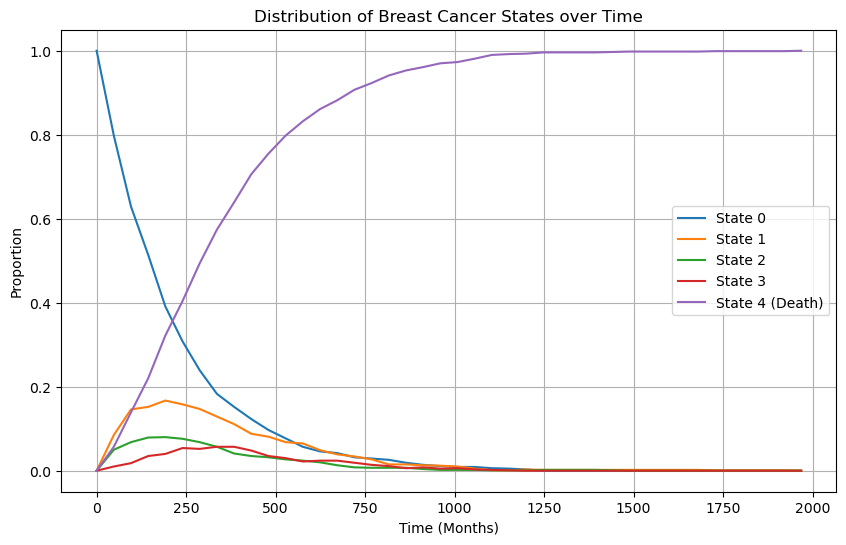

In [48]:
n = 1000
Y = generate_observed_timeseries(Q_treat, n=n)

Y_zero = [y - 1 for y in Y]

max_len = max(len(y) for y in Y_zero)

Y_mat = np.full((len(Y_zero), max_len), 4)

for i, y in enumerate(Y_zero):
    Y_mat[i, :len(y)] = y

times = np.arange(max_len) * 48

plt.figure(figsize=(10,6))

labels = [
    "State 0",
    "State 1",
    "State 2",
    "State 3",
    "State 4 (Death)"
]

for state in range(5):
    prop = np.mean(Y_mat == state, axis=0)
    plt.plot(times, prop, label=labels[state])

plt.xlabel("Time (Months)")
plt.ylabel("Proportion")
plt.title("Distribution of Breast Cancer States over Time")
plt.legend()
plt.grid(True)
plt.show()

In [62]:
def plot_stacked_state_distribution(Y):
    import numpy as np
    import matplotlib.pyplot as plt

    # Detect if states are 1–5 instead of 0–4
    min_state = min(min(y) for y in Y)
    if min_state == 1:
        Y = [np.array(y) - 1 for y in Y]

    lengths = [len(y) for y in Y]
    max_len = max(lengths)

    counts = np.zeros((max_len, 5))

    for y in Y:
        for k, s in enumerate(y):
            if 0 <= s <= 4:
                counts[k, s] += 1

    times = np.arange(0, 48 * max_len, 48)

    labels = ["0: Post-surgery", "1: Local", "2: Distant", "3: Both", "4: Death"]
    colors = ["#4C72B0", "#55A868", "#C44E52", "#8172B2", "#CCB974"]

    plt.figure(figsize=(14, 7))
    bottom = np.zeros(max_len)

    for state in range(5):
        plt.bar(times,
                counts[:, state],
                bottom=bottom,
                width=40,          # ← gør søjlerne brede og læsbare
                color=colors[state],
                label=labels[state])
        bottom += counts[:, state]

    plt.xlabel("Time (months)")
    plt.ylabel("Number of women")
    plt.title("Observed State Distribution at Each 48-Month Screening")
    plt.legend()
    plt.grid(axis='y', alpha=0.3)
    plt.show()


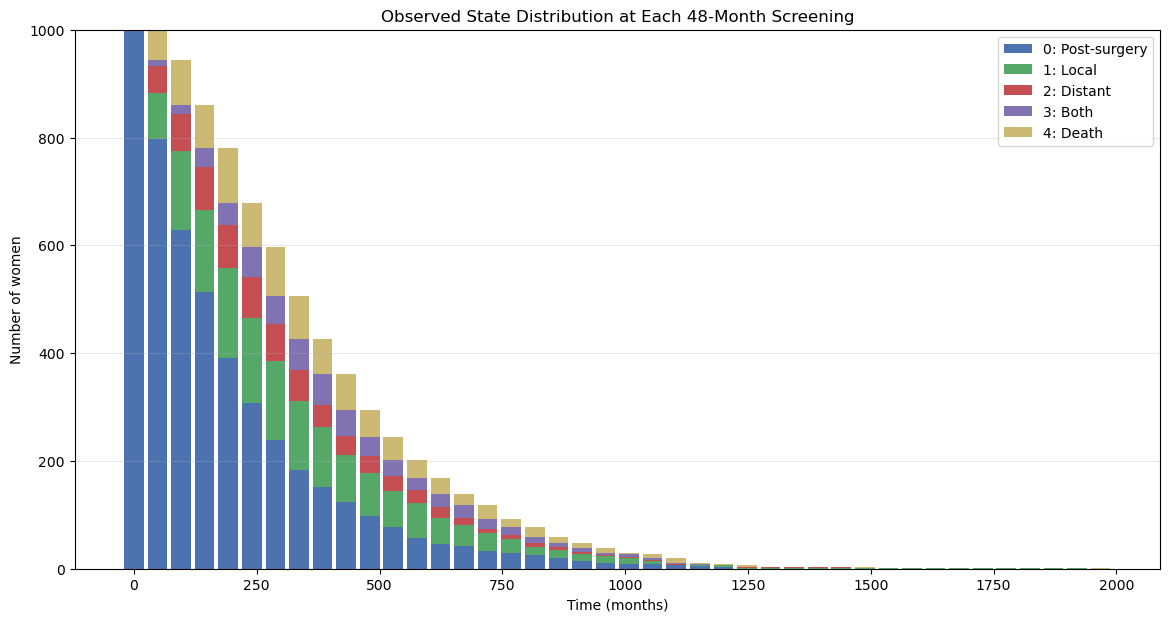

In [63]:
plot_stacked_state_distribution(Y)

## Task 13

In [49]:
random.seed(42)
np.random.seed(42)
def simulate_between_observations(Q, start_state, end_state, horizon=48):
    while True:
        times, states = simulate_ctmc(Q, start_state=start_state, max_time=horizon+1)

        # truncate at horizon
        if times[-1] > horizon:
            idx = np.searchsorted(times, horizon, side='right') - 1
            final_state = states[idx]
        else:
            final_state = states[-1]

        if final_state == end_state:
            # return full trajectory (times clipped at horizon)
            clipped_times = []
            clipped_states = []
            for t, s in zip(times, states):
                if t <= horizon:
                    clipped_times.append(t)
                    clipped_states.append(s)
            clipped_times.append(horizon)
            clipped_states.append(end_state)
            return np.array(clipped_times), np.array(clipped_states)

def reconstruct_full_trajectories(Y, Q):
    """
    For each observed time series Y(i), reconstruct a full CTMC trajectory.
    Returns list of (times, states).
    """
    full = []

    for obs in Y:
        traj_times = [0.0]
        traj_states = [obs[0]]

        for k in range(len(obs)-1):
            start = obs[k]
            end = obs[k+1]

            times, states = simulate_between_observations(Q, start, end)

            # shift times by current end time
            times = times + traj_times[-1]

            traj_times.extend(times[1:])
            traj_states.extend(states[1:])

        full.append((np.array(traj_times), np.array(traj_states)))

    return full

def compute_N_and_S(full_trajectories):
    N = np.zeros((5,5))
    S = np.zeros(5)

    for times, states in full_trajectories:
        for i in range(len(states)-1):
            s = states[i] - 1
            dt = times[i+1] - times[i]
            S[s] += dt

            s_next = states[i+1] - 1
            if s != s_next:
                N[s, s_next] += 1

    return N, S

def update_Q(N, S):
    Q_new = np.zeros((5,5))
    for i in range(5):
        for j in range(5):
            if i != j:
                Q_new[i,j] = N[i,j] / S[i] if S[i] > 0 else 0
        Q_new[i,i] = -Q_new[i].sum()
    return Q_new

def EM_algorithm(Y, Q0, tol=1e-3, max_iter=50):
    Q = Q0.copy()

    for k in range(max_iter):
        print(f"Iteration {k}")

        # E-step
        full = reconstruct_full_trajectories(Y, Q)

        # Compute sufficient statistics
        N, S = compute_N_and_S(full)

        # M-step
        Q_new = update_Q(N, S)

        # Check convergence
        if np.max(np.abs(Q_new - Q)) < tol:
            print("Converged")
            return Q_new

        Q = Q_new

    return Q


In [33]:
random.seed(42)
np.random.seed(42)

Q0 = np.random.uniform(0.001, 0.05, size=(5,5))
np.fill_diagonal(Q0, 0)
for i in range(5):
    Q0[i,i] = -Q0[i].sum()

In [34]:
random.seed(42)
np.random.seed(42)
Q_est = EM_algorithm(Y, Q0)

Iteration 0
Iteration 1
Iteration 2
Iteration 3
Iteration 4
Iteration 5
Iteration 6
Iteration 7
Iteration 8
Iteration 9
Iteration 10
Iteration 11
Iteration 12
Iteration 13
Iteration 14
Iteration 15
Iteration 16
Iteration 17
Iteration 18
Iteration 19
Iteration 20
Iteration 21
Converged


In [65]:
Q_est

array([[-4.82184349e-03,  2.64237023e-03,  1.05598372e-03,
         3.37529044e-05,  1.08973663e-03],
       [ 0.00000000e+00, -3.32335586e-02,  2.56361881e-02,
         2.63340401e-03,  4.96396656e-03],
       [ 0.00000000e+00,  5.87197183e-02, -6.43658451e-02,
         2.31788362e-03,  3.32824314e-03],
       [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        -8.96069676e-03,  8.96069676e-03],
       [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00, -0.00000000e+00]])